# Calibration of Gaia jitter, goodness of fit of sky paths



In [1]:
import numpy as np
from scipy import optimize, special, stats
import pandas as pd
import matplotlib.pyplot as plt

Define my functions.  

In [2]:
def get_F2(chisq_val, dof):
    """
    Convert a chi squared value to a Gaussian equivalent sigma.
    
    Arguments: chi squared value, degrees of freedom.
    
    If chisq_val=dof, the F2 value should be close to zero.  Higher
    chisq values will result in positive F2 values.
    """
    chisq_cdf = stats.chi2.cdf(chisq_val, dof)
    chisq_sf = stats.chi2.sf(chisq_val, dof)

    if chisq_sf < 1e-2:
        F2 = special.erfcinv(chisq_sf*2)*np.sqrt(2)
    else:
        F2 = special.erfinv(chisq_cdf*2 - 1)*np.sqrt(2)
    
    return F2

    
def get_XY(MA, ecc):
    """
    Compute the elliptical rectangular coordinates X and Y from an 
    array of mean anomalies and an eccentricity.  This is 
    inefficient; it's just meant for this demonstration notebook.
    I have an efficient Cython implementation if you want it.
    """

    EA = MA + ecc*np.sin(MA)/np.sqrt(1 - 2*ecc*np.cos(MA) + ecc**2)

    for i in range(10):   # Should be enough for convergence.  A good EA solver can be tricky; I'll be lazy.
        EA -= (MA - EA + ecc*np.sin(EA))/(ecc*np.cos(EA) - 1)

    X = np.cos(EA) - ecc
    Y = np.sin(EA)*np.sqrt(1 - ecc**2)
    return X, Y


def chisq_jitter_value(jitter, coef_matrix_noerrs, wobs, sigw, indx):
    """
    Clumsy way to compute a jitter value to make the distribution of
    z-scores of the leading minus the trailing fields have unit 
    variance.  Minimizing this function will yield a nonnegative
    jitter that will make this variance as close as possible to unity.
    An actual implementation should just probably use Newton-Raphson 
    to do root finding.
    """
    coef_matrix = coef_matrix_noerrs/sigw[np.newaxis, :]
    coef = np.linalg.lstsq(coef_matrix.T, wobs/sigw, rcond=None)[0]
    
    resid = wobs - coef@coef_matrix_noerrs
    
    zscore_resid = (resid[indx + 1] - resid[indx])
    # 2*jitter**2 because I am defining jitter per-epoch
    zscore_resid /= np.sqrt(sigw[indx + 1]**2 + sigw[indx]**2 + 2*jitter**2)
    return (np.std(zscore_resid) - 1)**2


def chisq_orbit(params_nonlin, t, sintheta, costheta, parfac, wobs, sigw, plot=False):
    
    """
    Compute chi squared for a Keplerian orbit plus five-parameter sky
    path.  Do a linear fit in all but period, eccentricity, and phase.
    Optionally plot the data.
    """
    
    tp, ecc, period = params_nonlin
    if ecc < 0 or ecc > 0.99: # Cap eccentricity at 0.99
        return np.inf
    
    MA = np.mod(2*np.pi*(t - tp)/period, 2*np.pi)
    X, Y = get_XY(MA, ecc)

    coef_matrix = np.asarray([sintheta, costheta, t*sintheta, t*costheta, parfac,
                              X*sintheta, Y*sintheta, X*costheta, Y*costheta])/sigw[np.newaxis, :]
    coef = np.linalg.lstsq(coef_matrix.T, wobs/sigw, rcond=None)[0]
    chisq = np.sum((wobs/sigw - coef@coef_matrix)**2)
        
    if not plot:
        return chisq  # for minimization
    else:
        # Plot 1000 points between the first and last observed epoch
        dt = min(period, t[-1] - t[0])
        tplot = np.linspace(t[0], t[0] + dt, 1000)

        MA_plot = np.mod(2*np.pi*(tplot - tp)/period, 2*np.pi)
        Xplot, Yplot = get_XY(MA_plot, ecc)
        
        B, G, A, F = coef[-4:] # Best-fit Thiele-Innes coefficients

        # -> units of mas
        orbit_plot_RA = 1e3*(B*Xplot + G*Yplot)
        orbit_plot_Dec = 1e3*(A*Xplot + F*Yplot)

        # -> measured points have the residuals added (measured minus
        # predicted positions).  Add these with the factors of
        # sin(theta) and cos(theta) to project along RA and Dec.
        # The second part, coef@coef_matrix*sigw, undoes the inverse
        # standard deviation scaling of the coefficient matrix and then
        # does matrix multiplication times the best-fit coefficients to
        # get the predicted (model) positions.

        resid = wobs - coef@coef_matrix*sigw
        orbit_points_RA = 1e3*(B*X + G*Y + resid*sintheta)
        orbit_points_Dec = 1e3*(A*X + F*Y + resid*costheta)

        plt.figure(figsize=(7, 7))
        plt.plot(orbit_plot_RA, orbit_plot_Dec)

        # RA and Dec components of the uncertainty
        err_RA, err_Dec = sigw*sintheta*1e3, sigw*costheta*1e3

        # Draw error bars as a bunch of short lines.
        plt.plot([orbit_points_RA - err_RA, orbit_points_RA + err_RA],
                 [orbit_points_Dec - err_Dec, orbit_points_Dec + err_Dec],
                 linewidth=1, color='k')

        plt.plot(orbit_points_RA, orbit_points_Dec, marker='o', linestyle=' ')
        plt.xlabel('Right Ascension Perturbation (mas)')
        plt.ylabel('Declination Perturbation (mas)')

Read in one csv file.  Choose the file here; you could play with other epoch astrometry and see how it works.

In [3]:
gaia_data = pd.read_csv('target_1.csv')

# Read in all of the relevant columns.

wobs = gaia_data.centroid_pos_al.values
sigw = gaia_data.centroid_pos_error_al.values
fov = gaia_data.field_of_view.values

theta = gaia_data.scan_pos_angle.values
costheta = np.cos(theta)
sintheta = np.sin(theta)
parfac = gaia_data.parallax_factor_al.values

juld = gaia_data.obs_time_tcb.values
ref_ep = 2457936.875
t = (juld - ref_ep)/365.25 # in Julian years

# Pick out the indices for which we have a leading/trailing field pair

indx = []
for i in range(len(wobs) - 1):
    if fov[i] != fov[i + 1] and np.abs(theta[i] - theta[i + 1]) < 0.1 and np.abs(juld[i] - juld[i + 1]) < 1:
        indx += [i]
    
indx = np.array(indx)        

# This is a linear fit, so write down the matrix of coefficients, normalized by the uncertainties.
# Here I am fitting a five-parameter model.

coef_matrix_noerrs = np.asarray([sintheta, costheta, t*sintheta, t*costheta, parfac])
jitter = optimize.minimize(chisq_jitter_value, [1e-3], args=(coef_matrix_noerrs, wobs, sigw, indx)).x[0]

print('The best-fit jitter is %.2f uas' % (1e3*np.abs(jitter)))

sigw = np.sqrt(sigw**2 + jitter**2)
coef_matrix = coef_matrix_noerrs/sigw[np.newaxis, :]
coef = np.linalg.lstsq(coef_matrix.T, wobs/sigw, rcond=None)[0]
chisq_val = np.sum((wobs/sigw - coef@coef_matrix)**2)

print('The best-fit parameters are', coef)
print('Chi squared is %.2f for %d D.O.F.' % (chisq_val, len(sigw) - 5))
print('The F2 value for chi squared is %.2f' % (get_F2(chisq_val, len(sigw) - 5)))

The best-fit jitter is 24.54 uas
The best-fit parameters are [ -0.13886245  -0.18707884   5.48990499 -24.10375157  16.16864038]
Chi squared is 993.94 for 97 D.O.F.
The F2 value for chi squared is 25.94


Now fit a five-parameter sky path plus a Keplerian orbit.  I'm just choosing a few starting guesses in period and picking the best fit from those nonlinear optimizations.  

Best-fit period: 6.199 years
Chi squared is 86.29 for 90 D.O.F.
The F2 value for chi squared with an orbit is -0.23


/Users/tbrandt/miniconda3/envs/jwst/lib/python3.11/site-packages/scipy/optimize/_optimize.py:2502: RuntimeWarning: invalid value encountered in scalar multiply
  tmp2 = (x - v) * (fx - fw)


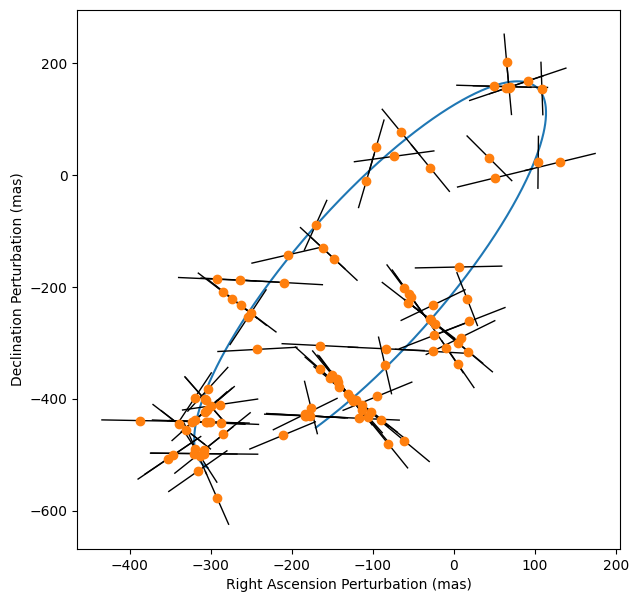

In [4]:
T0_guess = 1  # Phase
ecc_guess = 0.5  # Eccentricity

best_chisq = np.inf
for period_guess in [0.25, 0.5, 1, 2, 5, 10]:
    res = optimize.minimize(chisq_orbit, [T0_guess, ecc_guess, period_guess],
                            args=(t, sintheta, costheta, parfac, wobs, sigw), method='Powell')
    if res.fun < best_chisq:
        best_chisq = res.fun
        res_best = res
    
print("Best-fit period: %.3f years" % (res_best.x[2]))
print('Chi squared is %.2f for %d D.O.F.' % (best_chisq, len(sigw) - 12))
print('The F2 value for chi squared with an orbit is %.2f' % (get_F2(best_chisq, len(sigw) - 12)))

# Plot if desired
chisq_orbit(res_best.x, t, sintheta, costheta, parfac, wobs, sigw, plot=True)

### My results:

| Target Number | F2 (five parameter) | F2 (Keplerian orbit) |
| --- | --- | --- |
| 1 | 25.94 | $-$0.23 |
| 2 | $-$0.80 | $-$1.41 |
| 3 | 3.37 | 0.08 |
| 4 | 16.39 | 3.33 | 
| 5 | 13.55 | $-$0.42 |
| 6 | 1.95 | $-$0.19 |
| 7 | 26.68 | $-$0.74 |

### A note on the sensitivity of the jitter to the accuracy of the initial astrometric model: 

I compared the jitter recovered for Target 7 from a five parameter model to the jitter from a seven parameter model, and the jitter recovered for Target 1 from a five parameter model to the jitter from a Keplerian orbital fit:

| Target | Model | F2 Value | Inferred Jitter |
| --- | --- | --- | --- |
| 1 | Five-parameter | 25.94 | 24.54 $\mu$as |
| 1 | Keplerian Orbit | $-$0.23 | 24.45 $\mu$as |
| 7 | Five-parameter | 26.68 | 57.1 $\mu$as |
| 7 | Seven-parameter | $-$0.78 | 56.6 $\mu$as |

Despite the fact that the five-parameter model is a very poor fit to both stars, it gives almost the same inferred jitter as the more complex but much better-fitting models.  I conclude that fitting a five-parameter sky path for the purpose of inferring a jitter is ok even if a five-parameter sky path is a pretty poor fit.